# Model Improvement and Feature Engineering

In this notebook, I compare the Linear Regression baseline with non-linear tree-based regression models while keeping the same V3 feature set, preprocessing pipeline, chronological data split, and evaluation metrics. This allows the effect of changing the model to be evaluated fairly.

The workflow is divided into three stages:

Initial model comparison using the fixed V3 feature set.
Hyperparameter tuning using a separate chronological validation period.
Final candidate comparison on the final test period.

## 1. Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# load data
model_ready_data = pd.read_csv(
    "../data/processed/model_ready_hourly_rental_data.csv",
    parse_dates=["hour", "date"]
)

# define features and target
TARGET = "total_count"

NUMERIC_FEATURES = [
    "temperature_c",
    "humidity",
    "windspeed_kmh",
    "is_holiday",
]


CATEGORICAL_FEATURES = [
    "hour_of_day",
    "day_of_week",
    "month",
    "conditions",
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# split sets into: training, validation and test sets
model_data = (
    model_ready_data[["hour", *FEATURES, TARGET]]
    .sort_values("hour")
    .reset_index(drop=True)
)

split_index = int(len(model_data) * 0.8)

train_data = model_data.iloc[:split_index].copy()
test_data = model_data.iloc[split_index:].copy()

X_train = train_data[FEATURES]
X_test = test_data[FEATURES]
y_train = train_data[TARGET]
y_test = test_data[TARGET]

## 2. Helper Functions

In [2]:
# encoding helper
def build_preprocessor(numeric_features: list[str], categorical_features: list[str]) -> ColumnTransformer:
    """Create preprocessing for a selected feature set."""
    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                "passthrough",
                numeric_features,
            ),
            (
                "categorical",
                OneHotEncoder(
                    drop="first",
                    handle_unknown="ignore",
                ),
                categorical_features,
            ),
        ]
    )

In [3]:
# evalutation metrics
def evaluate_regression_model(
    model_name: str,
    estimator,
    numeric_features: list[str],
    categorical_features: list[str],
    X_train: pd.DataFrame,
    X_evaluation: pd.DataFrame,
    y_train: pd.Series,
    y_evaluation: pd.Series,
    evaluation_hours: pd.Series,
    evaluation_name: str,
) -> tuple[dict, pd.DataFrame, Pipeline]:
    """Train one regression pipeline and evaluate it on a selected time period."""
    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                build_preprocessor(
                    numeric_features=numeric_features,
                    categorical_features=categorical_features,
                ),
            ),
            ("regressor", estimator),
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred_train = pipeline.predict(X_train)
    y_pred_evaluation = pipeline.predict(X_evaluation)

    train_r2 = r2_score(y_train, y_pred_train)
    evaluation_r2 = r2_score(y_evaluation, y_pred_evaluation)

    result = {
        "model": model_name,
        "train_MAE": mean_absolute_error(y_train, y_pred_train),
        f"{evaluation_name}_MAE": mean_absolute_error(
            y_evaluation,
            y_pred_evaluation,
        ),
        "train_RMSE": np.sqrt(
            mean_squared_error(y_train, y_pred_train)
        ),
        f"{evaluation_name}_RMSE": np.sqrt(
            mean_squared_error(y_evaluation, y_pred_evaluation)
        ),
        "train_R2": train_r2,
        f"{evaluation_name}_R2": evaluation_r2,
        "R2_gap": train_r2 - evaluation_r2,
        "negative_predictions": int(
            (y_pred_evaluation < 0).sum()
        ),
    }

    predictions = pd.DataFrame(
        {
            "hour": evaluation_hours.reset_index(drop=True),
            "actual_total_count": y_evaluation.reset_index(drop=True),
            "predicted_total_count": y_pred_evaluation,
        }
    )

    predictions["residual"] = (
        predictions["actual_total_count"]
        - predictions["predicted_total_count"]
    )

    predictions["model"] = model_name

    return result, predictions, pipeline

## 3. Initial Model Evaluation
### Model 1: Baseline Model - Linear Regression

In [4]:
initial_results = []
initial_predictions = {}
initial_fitted_models = {}

linear_result, linear_predictions, linear_pipeline = evaluate_regression_model(
    model_name="Linear Regression Baseline",
    estimator=LinearRegression(),
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
    X_train=X_train,
    X_evaluation=X_test,
    y_train=y_train,
    y_evaluation=y_test,
    evaluation_hours=test_data["hour"],
    evaluation_name="test",
)

initial_results.append(linear_result)
initial_predictions["Linear Regression Baseline"] = linear_predictions
initial_fitted_models["Linear Regression Baseline"] = linear_pipeline

pd.DataFrame(initial_results).round(3)

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,R2_gap,negative_predictions
0,Linear Regression Baseline,72.517,111.517,100.151,159.746,0.64,0.475,0.165,354


### Model 2: Random Forest Regressor

In [5]:
random_forest = RandomForestRegressor(
    n_estimators=200, #200 trees
    random_state=42,
    n_jobs=-1,
)

rf_result, rf_predictions, rf_pipeline = evaluate_regression_model(
    model_name="Random Forest Regressor",
    estimator=random_forest,
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
    X_train=X_train,
    X_evaluation=X_test,
    y_train=y_train,
    y_evaluation=y_test,
    evaluation_hours=test_data["hour"],
    evaluation_name="test",
)

initial_results.append(rf_result)
initial_predictions["Random Forest Regressor"] = rf_predictions
initial_fitted_models["Random Forest Regressor"] = rf_pipeline

pd.DataFrame(initial_results).round(3)

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,R2_gap,negative_predictions
0,Linear Regression Baseline,72.517,111.517,100.151,159.746,0.640,0.475,0.165,354
1,Random Forest Regressor,16.551,86.216,25.622,122.239,0.976,0.693,0.284,0


### Model 3: Gradient Boosting Regressor

In [6]:
gradient_boosting = GradientBoostingRegressor(
    random_state=42,
)

gb_result, gb_predictions, gb_pipeline = evaluate_regression_model(
    model_name="Gradient Boosting Regressor",
    estimator=gradient_boosting,
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
    X_train=X_train,
    X_evaluation=X_test,
    y_train=y_train,
    y_evaluation=y_test,
    evaluation_hours=test_data["hour"],
    evaluation_name="test",
)

initial_results.append(gb_result)
initial_predictions["Gradient Boosting Regressor"] = gb_predictions
initial_fitted_models["Gradient Boosting Regressor"] = gb_pipeline

initial_model_comparison = (
    pd.DataFrame(initial_results)
    .sort_values("test_RMSE")
    .reset_index(drop=True)
)

initial_model_comparison.round(3)

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,R2_gap,negative_predictions
0,Random Forest Regressor,16.551,86.216,25.622,122.239,0.976,0.693,0.284,0
1,Gradient Boosting Regressor,62.056,105.635,87.451,151.274,0.726,0.529,0.196,45
2,Linear Regression Baseline,72.517,111.517,100.151,159.746,0.640,0.475,0.165,354


This result suggests that the demand contains important non-linear patterns and feature interactions that are not fully captured by the linear baseline. However, the strong training performance of Random Forest also indicates possible overfitting. Therefore, tree complexity will be examined using a separate chronological validation period before selecting a candidate configuration.

## 4. Hyperparameter Tuning
### Implement Validation set

In [7]:
# split sets into: training, validation and test sets
train_end = int(len(model_data) * 0.6)
validation_end = int(len(model_data) * 0.8)

train_data = model_data.iloc[:train_end].copy()
validation_data = model_data.iloc[train_end:validation_end].copy()

X_train_t = train_data[FEATURES]
y_train_t = train_data[TARGET]

X_validation = validation_data[FEATURES]
y_validation = validation_data[TARGET]

### Tuning max_depth for Random Forest

In [8]:
### Reference
validation_reference_result, validation_reference_predictions, validation_reference_pipeline = (
    evaluate_regression_model(
        model_name="Linear Regression Validation Reference",
        estimator=LinearRegression(),
        numeric_features=NUMERIC_FEATURES,
        categorical_features=CATEGORICAL_FEATURES,
        X_train=X_train_t,
        X_evaluation=X_validation,
        y_train=y_train_t,
        y_evaluation=y_validation,
        evaluation_hours=validation_data["hour"],
        evaluation_name="validation",
    )
)

pd.DataFrame([validation_reference_result]).round(3)

,model,train_MAE,validation_MAE,train_RMSE,validation_RMSE,train_R2,validation_R2,R2_gap,negative_predictions
0,Linear Regression Validation Reference,58.585,114.431,79.309,162.557,0.653,0.431,0.222,82


In [9]:
rf_depth_results = []
rf_depth_pipelines = {}

for depth in [5, 10, 15, 20, None]:
    model_name = f"Random Forest max_depth={depth}"

    estimator = RandomForestRegressor(
        n_estimators=200,
        max_depth=depth,
        random_state=42,
        n_jobs=-1,
    )

    result, predictions, pipeline = evaluate_regression_model(
        model_name=model_name,
        estimator=estimator,
        numeric_features=NUMERIC_FEATURES,
        categorical_features=CATEGORICAL_FEATURES,
        X_train=X_train_t,
        X_evaluation=X_validation,
        y_train=y_train_t,
        y_evaluation=y_validation,
        evaluation_hours=validation_data["hour"],
        evaluation_name="validation",
    )

    rf_depth_results.append(result)
    rf_depth_pipelines[model_name] = pipeline

rf_depth_comparison = (
    pd.DataFrame(rf_depth_results)
    .sort_values("validation_RMSE")
    .reset_index(drop=True)
)

rf_depth_comparison.round(3)

,model,train_MAE,validation_MAE,train_RMSE,validation_RMSE,train_R2,validation_R2,R2_gap,negative_predictions
0,Random Forest max_depth=None,12.263,95.126,19.118,129.394,0.980,0.639,0.340,0
1,Random Forest max_depth=20,22.279,97.571,32.463,131.846,0.942,0.626,0.316,0
2,Random Forest max_depth=15,31.710,102.836,44.529,137.873,0.891,0.591,0.300,0
3,Random Forest max_depth=10,48.671,118.043,64.273,151.439,0.772,0.506,0.266,0
4,Random Forest max_depth=5,72.551,141.942,92.039,179.637,0.533,0.305,0.227,0


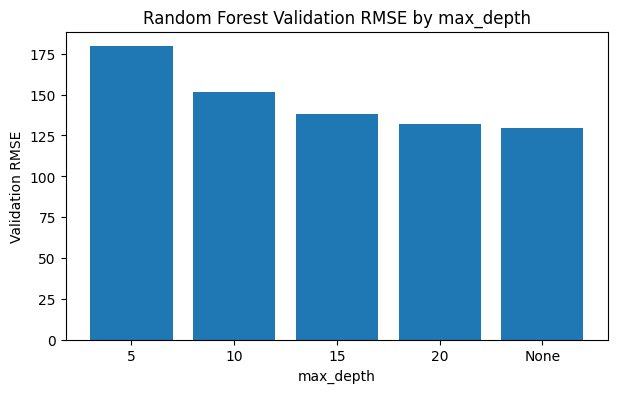

In [10]:
rf_depth_order = ["5", "10", "15", "20", "None"]

rf_plot_data = rf_depth_comparison.copy()
rf_plot_data["depth"] = (
    rf_plot_data["model"]
    .str.replace("Random Forest max_depth=", "", regex=False)
)

rf_plot_data["depth"] = pd.Categorical(
    rf_plot_data["depth"],
    categories=rf_depth_order,
    ordered=True,
)

rf_plot_data = rf_plot_data.sort_values("depth")

plt.figure(figsize=(7, 4))
plt.bar(
    rf_plot_data["depth"],
    rf_plot_data["validation_RMSE"],
)
plt.title("Random Forest Validation RMSE by max_depth")
plt.xlabel("max_depth")
plt.ylabel("Validation RMSE")
plt.show()

For Random Forest, validation performance improved as tree depth increased. Among the tested settings, max_depth=None achieved the lowest validation RMSE, although its high training score and larger train-validation R² gap indicate possible overfitting.

### Tuning max_depth of Gardient Boosting

In [11]:
gb_depth_results = []
gb_depth_pipelines = {}

for depth in [1, 2, 3, 4, 5, 6, 8, None]:
    model_name = f"Gradient Boosting max_depth={depth}"

    estimator = GradientBoostingRegressor(
        max_depth=depth,
        random_state=42,
    )

    result, predictions, pipeline = evaluate_regression_model(
        model_name=model_name,
        estimator=estimator,
        numeric_features=NUMERIC_FEATURES,
        categorical_features=CATEGORICAL_FEATURES,
        X_train=X_train_t,
        X_evaluation=X_validation,
        y_train=y_train_t,
        y_evaluation=y_validation,
        evaluation_hours=validation_data["hour"],
        evaluation_name="validation",
    )

    gb_depth_results.append(result)
    gb_depth_pipelines[model_name] = pipeline

gb_depth_comparison = (
    pd.DataFrame(gb_depth_results)
    .sort_values("validation_RMSE")
    .reset_index(drop=True)
)

gb_depth_comparison.round(3)

,model,train_MAE,validation_MAE,train_RMSE,validation_RMSE,train_R2,validation_R2,R2_gap,negative_predictions
0,Gradient Boosting max_depth=8,22.439,97.301,31.899,130.298,0.944,0.634,0.309,90
1,Gradient Boosting max_depth=6,31.552,98.952,43.782,133.471,0.894,0.616,0.278,70
2,Gradient Boosting max_depth=None,0.041,99.163,1.839,137.796,1.000,0.591,0.409,0
3,Gradient Boosting max_depth=5,36.780,101.569,50.650,138.120,0.858,0.589,0.269,47
4,Gradient Boosting max_depth=4,43.156,106.490,58.643,145.789,0.810,0.542,0.268,12
5,Gradient Boosting max_depth=3,50.283,112.437,68.315,155.753,0.742,0.478,0.265,7
6,Gradient Boosting max_depth=2,58.483,121.097,78.796,167.470,0.657,0.396,0.261,1
7,Gradient Boosting max_depth=1,72.028,142.752,93.650,191.016,0.516,0.214,0.302,0


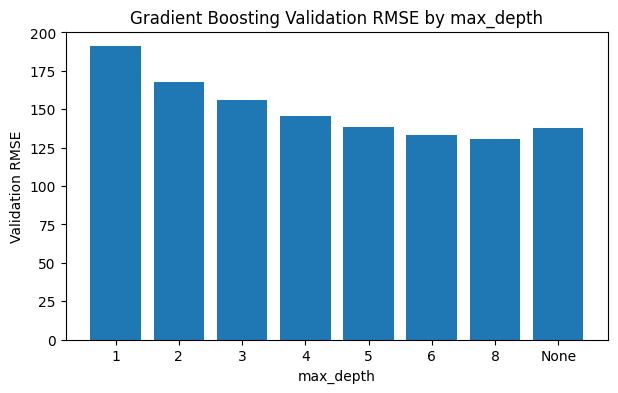

In [12]:
gb_depth_order = ["1", "2", "3", "4", "5", "6", "8", "None"]

gb_plot_data = gb_depth_comparison.copy()
gb_plot_data["depth"] = (
    gb_plot_data["model"]
    .str.replace("Gradient Boosting max_depth=", "", regex=False)
)

gb_plot_data["depth"] = pd.Categorical(
    gb_plot_data["depth"],
    categories=gb_depth_order,
    ordered=True,
)

gb_plot_data = gb_plot_data.sort_values("depth")

plt.figure(figsize=(7, 4))
plt.bar(
    gb_plot_data["depth"],
    gb_plot_data["validation_RMSE"],
)
plt.title("Gradient Boosting Validation RMSE by max_depth")
plt.xlabel("max_depth")
plt.ylabel("Validation RMSE")
plt.show()

For Gradient Boosting, increasing base-tree depth substantially improved validation performance compared with shallower trees. The best tested configuration was max_depth=8. In contrast, the unrestricted-depth version fitted the training period almost perfectly but performed worse on the validation period, indicating overfitting.

Based on validation RMSE, Random Forest with n_estimators=200 and max_depth=None, together with Gradient Boosting using max_depth=8, are selected for the final V3 feature comparison.

## 5. Improved Model Comparision
From last section we have found out best  

In [13]:
final_candidate_models = {
    "Linear Regression Baseline": LinearRegression(),

    "Random Forest tuned": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1,
    ),

    "Gradient Boosting tuned": GradientBoostingRegressor(
        max_depth=8,
        random_state=42,
    ),
}

final_results = []
final_predictions = {}
final_fitted_models = {}

for model_name, estimator in final_candidate_models.items():
    result, predictions, pipeline = evaluate_regression_model(
        model_name=model_name,
        estimator=estimator,
        numeric_features=NUMERIC_FEATURES,
        categorical_features=CATEGORICAL_FEATURES,
        X_train=X_train,
        X_evaluation=X_test,
        y_train=y_train,
        y_evaluation=y_test,
        evaluation_hours=test_data["hour"],
        evaluation_name="test",
    )

    final_results.append(result)
    final_predictions[model_name] = predictions
    final_fitted_models[model_name] = pipeline

final_model_comparison = (
    pd.DataFrame(final_results)
    .sort_values("test_RMSE")
    .reset_index(drop=True)
)

final_model_comparison.round(3)

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,R2_gap,negative_predictions
0,Random Forest tuned,16.551,86.216,25.622,122.239,0.976,0.693,0.284,0
1,Gradient Boosting tuned,31.861,91.777,44.807,126.370,0.928,0.672,0.256,140
2,Linear Regression Baseline,72.517,111.517,100.151,159.746,0.640,0.475,0.165,354


In [14]:
baseline_row = final_model_comparison.loc[
    final_model_comparison["model"] == "Linear Regression Baseline"
].iloc[0]

best_model_row = final_model_comparison.iloc[0]

rmse_improvement_pct = (
    (baseline_row["test_RMSE"] - best_model_row["test_RMSE"])
    / baseline_row["test_RMSE"]
    * 100
)

mae_improvement_pct = (
    (baseline_row["test_MAE"] - best_model_row["test_MAE"])
    / baseline_row["test_MAE"]
    * 100
)

r2_improvement = (
    best_model_row["test_R2"]
    - baseline_row["test_R2"]
)

print(f"Best final model: {best_model_row['model']}")
print(f"Test RMSE reduction vs baseline: {rmse_improvement_pct:.2f}%")
print(f"Test MAE reduction vs baseline:  {mae_improvement_pct:.2f}%")
print(f"Test R² increase vs baseline:    {r2_improvement:.3f}")

Best final model: Random Forest tuned
Test RMSE reduction vs baseline: 23.48%
Test MAE reduction vs baseline:  22.69%
Test R² increase vs baseline:    0.218


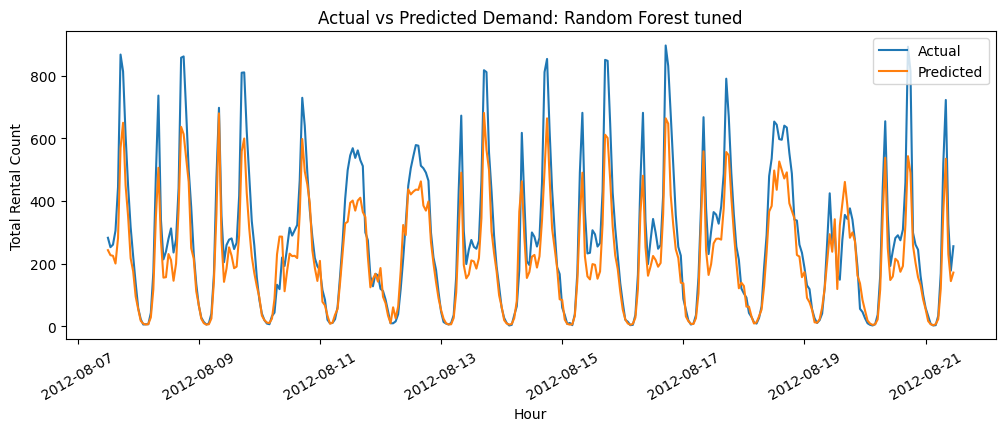

In [15]:
best_model_name = final_model_comparison.iloc[0]["model"]
best_predictions = final_predictions[best_model_name]
plot_predictions = best_predictions.head(24 * 14)

plt.figure(figsize=(12, 4))

plt.plot(
    plot_predictions["hour"],
    plot_predictions["actual_total_count"],
    label="Actual",
)

plt.plot(
    plot_predictions["hour"],
    plot_predictions["predicted_total_count"],
    label="Predicted",
)

plt.title(f"Actual vs Predicted Demand: {best_model_name}")
plt.xlabel("Hour")
plt.ylabel("Total Rental Count")
plt.xticks(rotation=30)
plt.legend()
plt.show()

Among the evaluated models, the tuned Random Forest Regressor achieved the best performance with the lowest test RMSE and the highest test R². The tuned Gradient Boosting model also improved substantially over the baseline, but its test performance remained slightly below Random Forest and it still produced negative predictions. 

The prediction plot further shows that Random Forest captures the general daily demand pattern well, although it tends to underestimate some of the highest rental peaks.

Further model improvement could include feature engineering and additional hyperparameter tuning such as `min_samples_leaf` and `max_features` for Random Forest, `learning_rate` and `n_estimators` for Gradient Boosting.

## 6. Feature Enigneering
### 6.1 Create engineered features

In [17]:
engineered_data = model_ready_data.copy()

# rush_hour
engineered_data["rush_hour"] = engineered_data["hour_of_day"].isin(
    [7, 8, 9, 16, 17, 18]
).astype(int)


# workday
engineered_data["is_workday"] = (
    (engineered_data["day_of_week"] < 5)
    & (engineered_data["is_holiday"] == 0)
).astype(int)


# season 
def get_season(month):
    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    else:
        return "autumn"

engineered_data["season"] = engineered_data["month"].apply(get_season)


# cyclical encoding for: hour, weekdays and month
engineered_data["hour_sin"] = np.sin(2 * np.pi * engineered_data["hour_of_day"] / 24)
engineered_data["hour_cos"] = np.cos(2 * np.pi * engineered_data["hour_of_day"] / 24)

engineered_data["weekday_sin"] = np.sin(2 * np.pi * engineered_data["day_of_week"] / 7)
engineered_data["weekday_cos"] = np.cos(2 * np.pi * engineered_data["day_of_week"] / 7)

engineered_data["month_sin"] = np.sin(2 * np.pi * (engineered_data["month"] - 1) / 12)
engineered_data["month_cos"] = np.cos(2 * np.pi * (engineered_data["month"] - 1) / 12)

engineered_data.head()

,hour,direct_count,registered_count,total_count,date,hour_of_day,day_of_week,month,is_weekend,conditions,...,is_holiday,is_workday,rush_hour,season,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos
0,2011-01-01 00:00:00,3,13,16,2011-01-01,0,5,1,1,clear,...,0,0,0,winter,0.000000,1.000000,-0.974928,-0.222521,0.0,1.0
1,2011-01-01 01:00:00,8,32,40,2011-01-01,1,5,1,1,clear,...,0,0,0,winter,0.258819,0.965926,-0.974928,-0.222521,0.0,1.0
2,2011-01-01 02:00:00,5,27,32,2011-01-01,2,5,1,1,clear,...,0,0,0,winter,0.500000,0.866025,-0.974928,-0.222521,0.0,1.0
3,2011-01-01 03:00:00,3,10,13,2011-01-01,3,5,1,1,clear,...,0,0,0,winter,0.707107,0.707107,-0.974928,-0.222521,0.0,1.0
4,2011-01-01 04:00:00,0,1,1,2011-01-01,4,5,1,1,clear,...,0,0,0,winter,0.866025,0.500000,-0.974928,-0.222521,0.0,1.0


Time-related variables like hour, weekdays and month are cyclical rather than linear, because:
- hour 23 is close to hour 0
- Sunday is close to Monday
- December is close to January